<a href="https://colab.research.google.com/github/angeellnt/Probabilidad-y-Estadistica/blob/main/Unidad4/Practica1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Probabilidad y estadistica
## Unidad 4
**Practica 1. 500 Alumnos**

Facilitador: Dr. Jose Gabriel Rodriguez Rivas

Alumno: Angel Alexander Rios Silva



--- Ejercicio 2: Tómbola ---
Suma probabilidades: 1.0
Valor esperado E(X): 8.5
Varianza: 142.75
Desviación Estándar: 11.947803145348521
Acumulada F(x): [0.5  0.8  0.95 1.  ]

--- Distribución Normal: Estudiantes ITD ---
Probabilidad < 75kg: 0.8944 | Estudiantes: 447.18
Probabilidad < 62kg: 0.0228 | Estudiantes: 11.38
Probabilidad > 79kg: 0.0122 | Estudiantes: 6.11



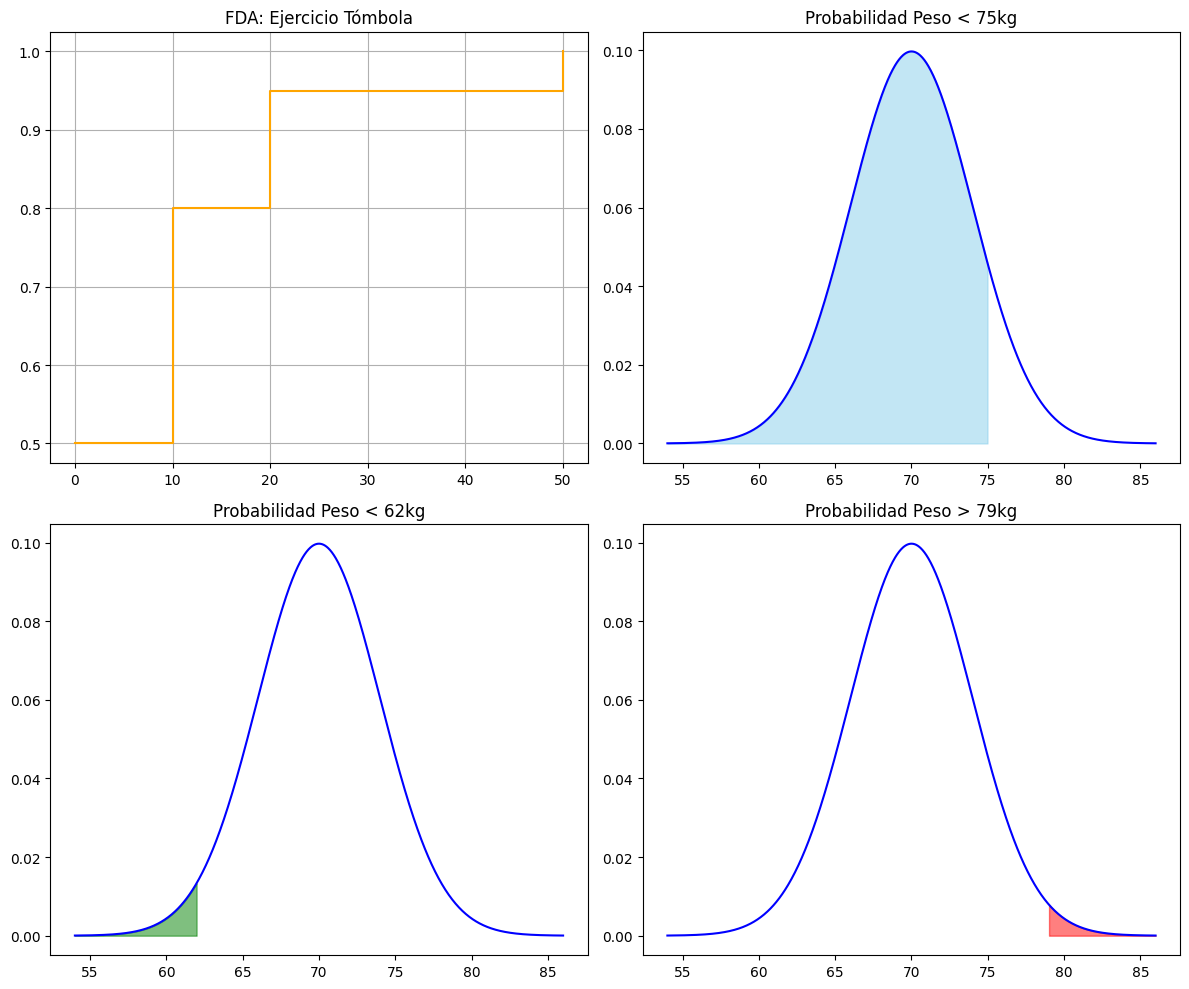

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x_tomb = [0, 10, 20, 50]
p_tomb = [0.50, 0.30, 0.15, 0.05]

suma_p = sum(p_tomb)
esperanza_tomb = sum(xi * pi for xi, pi in zip(x_tomb, p_tomb))
varianza_tomb = sum(((xi - esperanza_tomb)**2) * pi for xi, pi in zip(x_tomb, p_tomb))
desv_tomb = varianza_tomb**0.5
f_acum_tomb = np.cumsum(p_tomb)

print(f"--- Ejercicio 2: Tómbola ---")
print(f"Suma probabilidades: {suma_p}")
print(f"Valor esperado E(X): {esperanza_tomb}")
print(f"Varianza: {varianza_tomb}")
print(f"Desviación Estándar: {desv_tomb}")
print(f"Acumulada F(x): {f_acum_tomb}\n")

media = 70
desv_std = 4
total_estudiantes = 500
x_curva = np.linspace(media - 4*desv_std, media + 4*desv_std, 1000)
y_curva = norm.pdf(x_curva, media, desv_std)

limite_75 = 75
prob_75 = norm.cdf(limite_75, media, desv_std)
cant_75 = total_estudiantes * prob_75

limite_62 = 62
prob_62 = norm.cdf(limite_62, media, desv_std)
cant_62 = total_estudiantes * prob_62

limite_79 = 79
prob_79 = 1 - norm.cdf(limite_79, media, desv_std)
cant_79 = total_estudiantes * prob_79

print(f"--- Distribución Normal: Estudiantes ITD ---")
print(f"Probabilidad < 75kg: {prob_75:.4f} | Estudiantes: {cant_75:.2f}")
print(f"Probabilidad < 62kg: {prob_62:.4f} | Estudiantes: {cant_62:.2f}")
print(f"Probabilidad > 79kg: {prob_79:.4f} | Estudiantes: {cant_79:.2f}\n")


fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].step(x_tomb, f_acum_tomb, where='post', color='orange')
axs[0, 0].set_title('FDA: Ejercicio Tómbola')
axs[0, 0].grid(True)

axs[0, 1].plot(x_curva, y_curva, 'b')
axs[0, 1].fill_between(x_curva, y_curva, where=(x_curva <= limite_75), color='skyblue', alpha=0.5)
axs[0, 1].set_title('Probabilidad Peso < 75kg')

axs[1, 0].plot(x_curva, y_curva, 'b')
axs[1, 0].fill_between(x_curva, y_curva, where=(x_curva <= limite_62), color='green', alpha=0.5)
axs[1, 0].set_title('Probabilidad Peso < 62kg')

axs[1, 1].plot(x_curva, y_curva, 'b')
axs[1, 1].fill_between(x_curva, y_curva, where=(x_curva >= limite_79), color='red', alpha=0.5)
axs[1, 1].set_title('Probabilidad Peso > 79kg')

plt.tight_layout()
plt.show()